### Poređenje algoritama za preporuku (Two-Tower, Matrix Factorization, Deep Learning)

In [234]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

In [235]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

In [421]:
import random
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [236]:
anime = pd.read_csv('data/anime.csv')
ratings = pd.read_csv('data/rating.csv')

In [237]:
print('anime:', anime.shape)

anime: (12294, 7)


In [238]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [239]:
anime.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB


In [240]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [241]:
anime.dtypes

anime_id      int64
name            str
genre           str
type            str
episodes        str
rating      float64
members       int64
dtype: object

In [242]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [243]:
print('ratings:', ratings.shape)

ratings: (7813737, 3)


In [244]:
ratings.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [245]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [246]:
ratings.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [247]:
ratings.dtypes

user_id     int64
anime_id    int64
rating      int64
dtype: object

In [248]:
ratings.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [249]:
ratings['rating'].value_counts()

rating
 8     1646019
-1     1476496
 7     1375287
 9     1254096
 10     955715
 6      637775
 5      282806
 4      104291
 3       41453
 2       23150
 1       16649
Name: count, dtype: int64

#### Exploratory Data Analysis (EDA)

This section shows basic statistics and plots to understand `ratings` and `anime` distributions, sparsity, and genre information.

In [250]:
sns.set(style='whitegrid')

In [251]:
n_users = ratings['user_id'].nunique()
n_items = anime['anime_id'].nunique()

interactions = len(ratings)
sparsity = 1 - interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {interactions}")
print(f"Sparsity: {sparsity:.6f}")

Users: 73515
Items: 12294
Interactions: 7813737
Sparsity: 0.991355


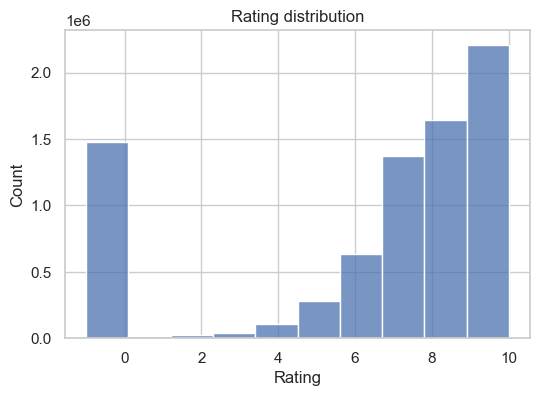

In [252]:
plt.figure(figsize=(6,4))
sns.histplot(ratings['rating'], bins=10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

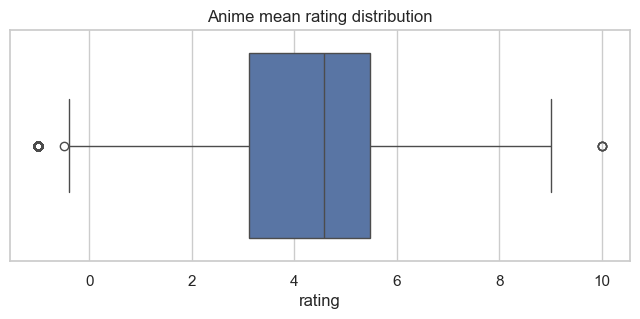

In [253]:
anime_mean = ratings.groupby('anime_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=anime_mean)
plt.title('Anime mean rating distribution')
plt.show()

In [254]:
ratings_work = ratings[ratings["rating"] != -1].copy()

ratings_work.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [255]:
ratings_work.describe()

,user_id,anime_id,rating
count,6.337241e+06,6.337241e+06,6.337241e+06
mean,3.674791e+04,8.902866e+03,7.808497e+00
std,2.101340e+04,8.882000e+03,1.572496e+00
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.898400e+04,1.239000e+03,7.000000e+00
50%,3.681500e+04,6.213000e+03,8.000000e+00
75%,5.487300e+04,1.407500e+04,9.000000e+00
max,7.351600e+04,3.447500e+04,1.000000e+01


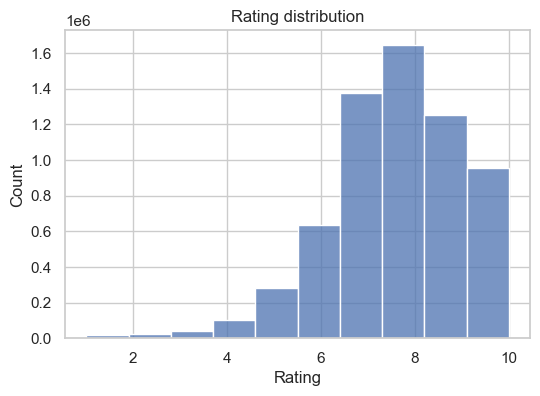

In [256]:
plt.figure(figsize=(6,4))
sns.histplot(ratings_work['rating'], bins=10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

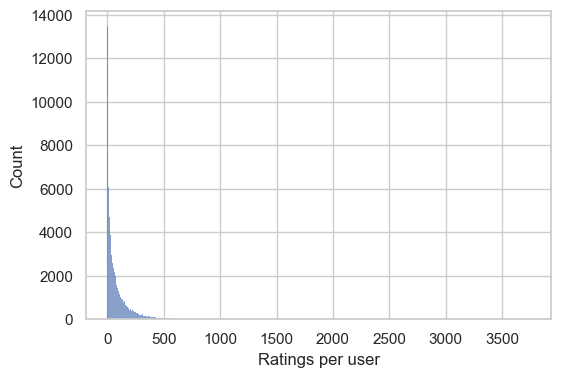

In [257]:
user_counts = ratings_work.groupby('user_id').size()

plt.figure(figsize=(6,4))
sns.histplot(user_counts)
plt.xlabel('Ratings per user')
plt.show()

/var/folders/82/h_3rsy994nq910bxmgv6kh680000gn/T/ipykernel_39069/3760345753.py:12: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/recsys/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


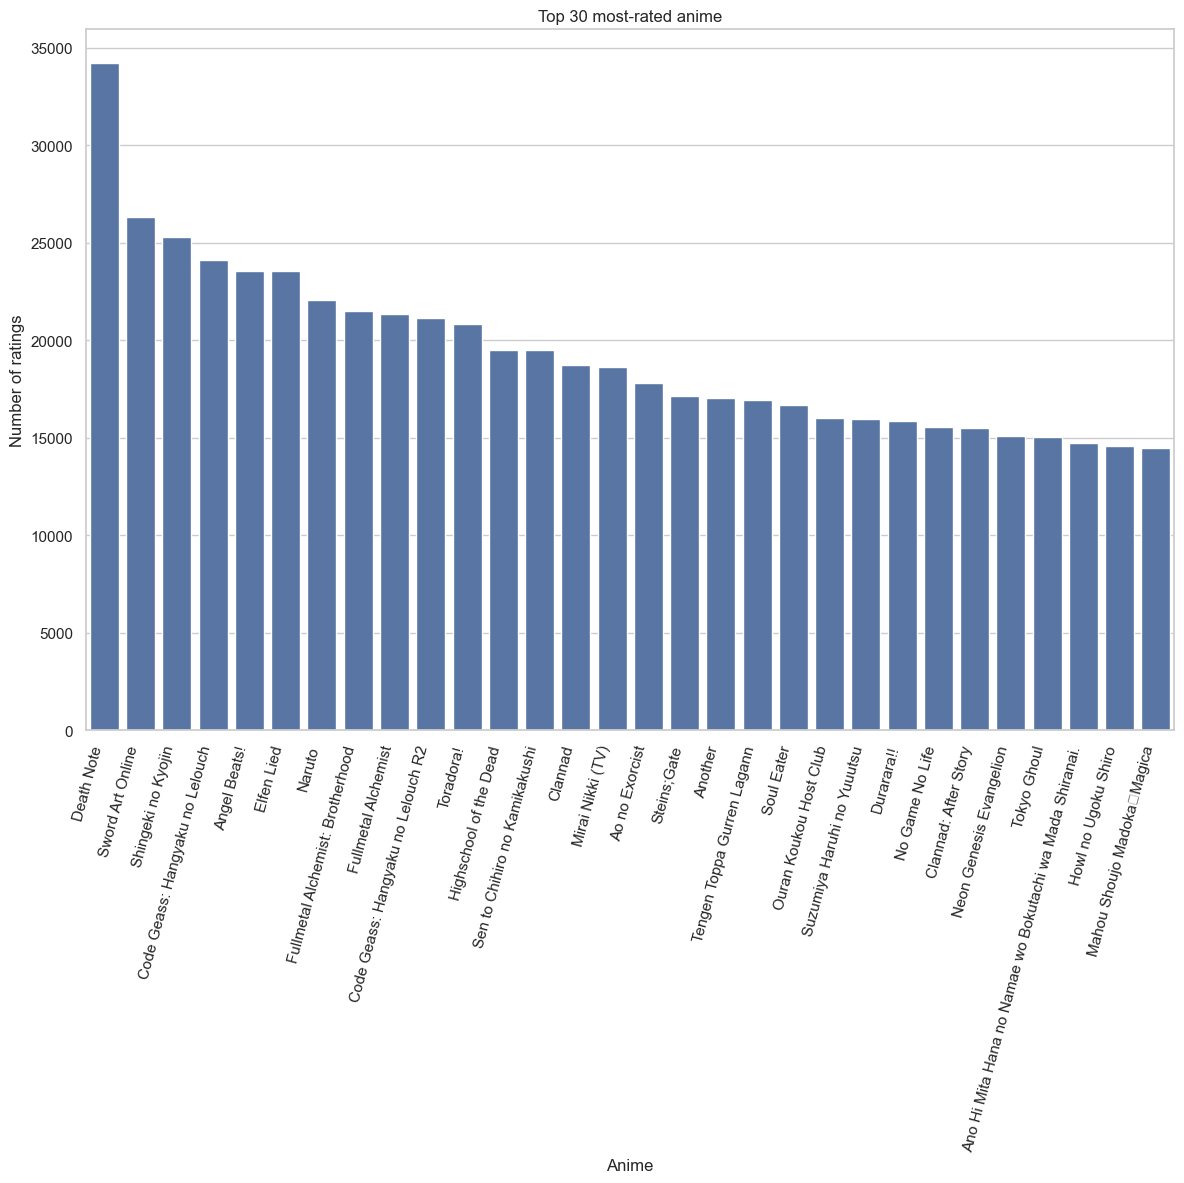

In [258]:

item_counts = ratings_work.groupby('anime_id').size().sort_values(ascending=False)
top30 = item_counts.head(30).reset_index().merge(anime[['anime_id','name']], on='anime_id', how='left')



plt.figure(figsize=(12,12))
sns.barplot(x='name', y=0, data=top30)
plt.xticks(rotation=75, ha='right')
plt.title('Top 30 most-rated anime')
plt.ylabel('Number of ratings')
plt.xlabel('Anime')
plt.tight_layout()
plt.show()

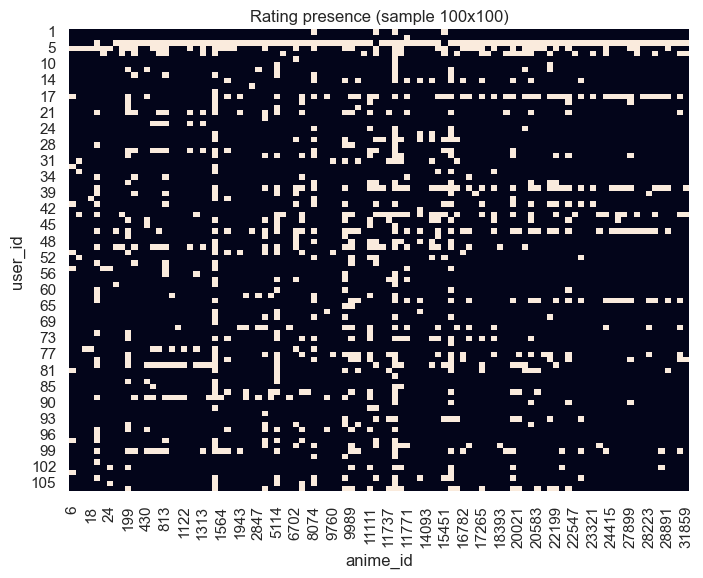

In [259]:
sample_users = ratings_work['user_id'].unique()[:100]
sample_items = ratings_work['anime_id'].unique()[:100]

sample = ratings_work[ratings_work['user_id'].isin(sample_users) & ratings_work['anime_id'].isin(sample_items)]
pivot = sample.pivot_table(index='user_id', columns='anime_id', values='rating')

plt.figure(figsize=(8,6))
sns.heatmap(pivot.notna(), cbar=False)
plt.title('Rating presence (sample 100x100)')
plt.show()

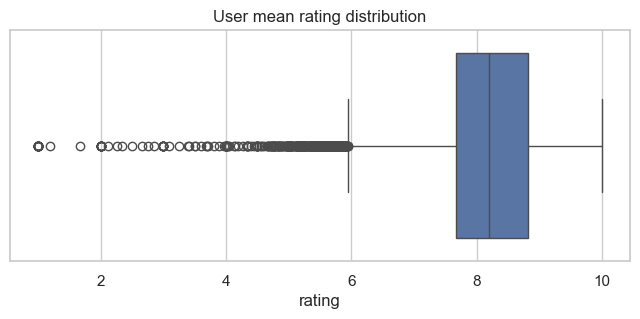

In [260]:
user_mean = ratings_work.groupby('user_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=user_mean)
plt.title('User mean rating distribution')
plt.show()

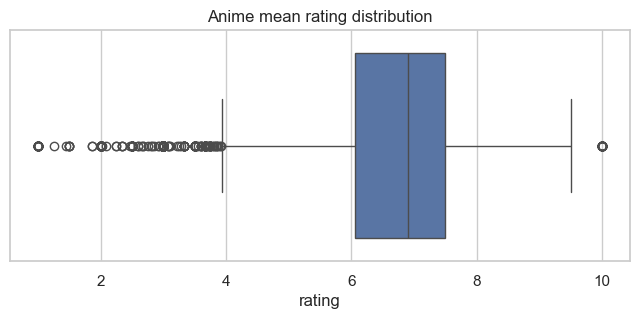

In [261]:

anime_mean = ratings_work.groupby('anime_id')['rating'].mean()

plt.figure(figsize=(8,3))
sns.boxplot(x=anime_mean)
plt.title('Anime mean rating distribution')
plt.show()

In [262]:
n_users = ratings_work['user_id'].nunique()
n_items = anime['anime_id'].nunique()

interactions = len(ratings_work)
sparsity = 1 - interactions / (n_users * n_items)

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {interactions}")
print(f"Sparsity: {sparsity:.6f}")

Users: 69600
Items: 12294
Interactions: 6337241
Sparsity: 0.992594


<Axes: ylabel='Count'>

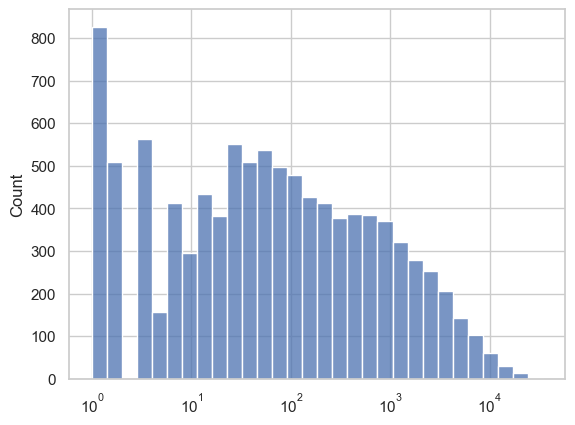

In [263]:
sns.histplot(item_counts, log_scale=True)

In [264]:
(user_counts < 5)

user_id
1         True
2         True
3        False
5        False
7        False
         ...  
73512    False
73513    False
73514     True
73515    False
73516     True
Length: 69600, dtype: bool

### Data Preprocessing

Filter low-activity users and rare items, create ID mappings, and split into train/test sets for model evaluation.

In [265]:
MIN_USER_POS = 5
MIN_ITEM_POS = 20   
POS_THRESHOLD = 7

In [266]:
ratings_work["interaction"] = (ratings_work["rating"] >= POS_THRESHOLD).astype(int)

ratings_pos = ratings_work[ratings_work["interaction"] == 1][["user_id", "anime_id"]].drop_duplicates()

print("Positive interactions:", len(ratings_pos))
ratings_pos.head()


Positive interactions: 5231113


,user_id,anime_id
47,1,8074
81,1,11617
83,1,11757
101,1,15451
153,2,11771


In [267]:
user_pos_counts = ratings_pos["user_id"].value_counts()
valid_users = user_pos_counts[user_pos_counts >= MIN_USER_POS].index

valid_users

Index([57620, 45659, 65840, 59643, 42635, 28196,  9032, 11536, 53698, 51270,
       ...
       72916, 72927, 72969, 72972, 73199, 73218, 73219, 73355, 73433, 73436],
      dtype='int64', name='user_id', length=60384)

In [268]:
ratings_filtered = ratings_pos[ratings_pos["user_id"].isin(valid_users)].copy()

ratings_filtered.info()

<class 'pandas.DataFrame'>
Index: 5211321 entries, 156 to 7813734
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
dtypes: int64(2)
memory usage: 119.3 MB


In [269]:
item_pos_counts = ratings_filtered["anime_id"].value_counts()
valid_items = item_pos_counts[item_pos_counts >= MIN_ITEM_POS].index

valid_items

Index([ 1535, 16498,  1575, 11757,  6547,  5114,  2904,   226,   121,  4224,
       ...
        4031,  3833, 18959,  4701, 24745,  2676,  1788,  5993,   211, 19569],
      dtype='int64', name='anime_id', length=5609)

In [270]:
ratings_filtered = ratings_filtered[ratings_filtered["anime_id"].isin(valid_items)]

ratings_filtered.info()

<class 'pandas.DataFrame'>
Index: 5190808 entries, 156 to 7813734
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
dtypes: int64(2)
memory usage: 118.8 MB


In [271]:
print(f"Original ratings rows: {len(ratings)}")
print(f"Filtered positive interactions: {len(ratings_filtered)}")

print(f"Users kept: {ratings_filtered['user_id'].nunique()} (min positives: {MIN_USER_POS})")
print(f"Items kept: {ratings_filtered['anime_id'].nunique()} (min positives: {MIN_ITEM_POS})")

Original ratings rows: 7813737
Filtered positive interactions: 5190808
Users kept: 60384 (min positives: 5)
Items kept: 5609 (min positives: 20)


In [272]:

user_enc = LabelEncoder()
item_enc = LabelEncoder()

ratings_filtered["user_idx"] = user_enc.fit_transform(ratings_filtered["user_id"]).astype(int)
ratings_filtered["item_idx"] = item_enc.fit_transform(ratings_filtered["anime_id"]).astype(int)

idx2item = {int(i): int(aid) for i, aid in enumerate(item_enc.classes_)}

idx2user = {int(i): int(uid) for i, uid in enumerate(user_enc.classes_)}

n_users = ratings_filtered["user_idx"].nunique()
n_items = ratings_filtered["item_idx"].nunique()

print("Dense mapping done.")
print("n_users:", n_users, "n_items:", n_items)
print("max item_idx:", int(ratings_filtered["item_idx"].max()))


Dense mapping done.
n_users: 60384 n_items: 5609
max item_idx: 5608


In [273]:
n_interactions = len(ratings_filtered)

sparsity_clean = 1 - n_interactions / (n_users * n_items)

print("Clean sparsity:", sparsity_clean)

Clean sparsity: 0.9846740414446726


In [274]:
test_df = ratings_filtered.groupby("user_idx").sample(
    n=1,
    random_state=42
)

train_df = ratings_filtered.drop(test_df.index)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [275]:
print("Per-user holdout split:")
print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))

Per-user holdout split:
Train interactions: 5130424
Test interactions: 60384


In [276]:
print("Users in train:", train_df["user_idx"].nunique())
print("Users in test:", test_df["user_idx"].nunique())

Users in train: 60384
Users in test: 60384


In [277]:

assert train_df.merge(test_df, on=["user_idx", "item_idx"]).empty
print("No overlap between train and test")

No overlap between train and test


In [278]:
train_user_items = (
    train_df.groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

test_user_item = (
    test_df.groupby("user_idx")["item_idx"]
    .first()
    .to_dict()
)

print("Users in train_user_items:", len(train_user_items))
print("Users in test_user_item:", len(test_user_item))


Users in train_user_items: 60384
Users in test_user_item: 60384


In [279]:
SAMPLE_USER_IDX = 0 

sample_user = list(test_user_item.keys())[SAMPLE_USER_IDX]

print("sample_user_idx:", sample_user)
print("original user_id:", idx2user[sample_user])


sample_user_idx: 0
original user_id: 3


In [280]:
print("seen items (train) for sample_user:", len(train_user_items.get(int(sample_user), set())))


seen items (train) for sample_user: 71


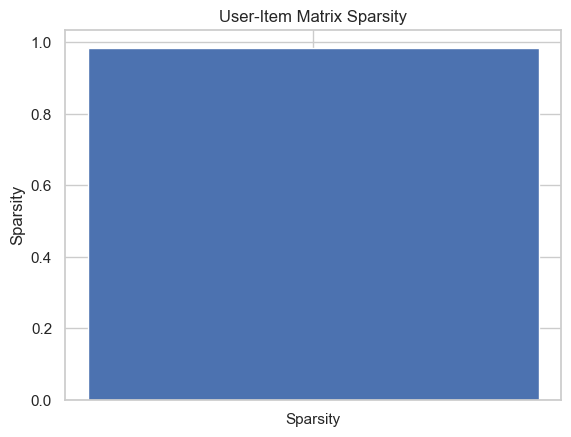

Sparsity: 0.9846740414446726


In [281]:
sparsity = 1 - (len(ratings_filtered) / (n_users * n_items))

plt.figure()
plt.bar(["Sparsity"], [sparsity])
plt.title("User-Item Matrix Sparsity")
plt.ylabel("Sparsity")
plt.show()

print("Sparsity:", sparsity)

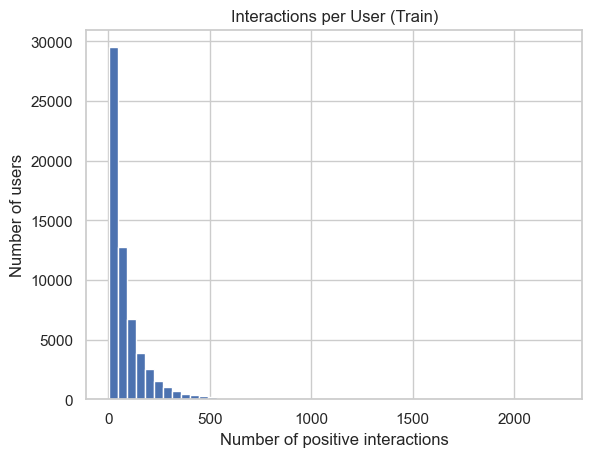

In [282]:
user_counts = train_df["user_idx"].value_counts()

plt.figure()
plt.hist(user_counts, bins=50)
plt.title("Interactions per User (Train)")
plt.xlabel("Number of positive interactions")
plt.ylabel("Number of users")
plt.show()

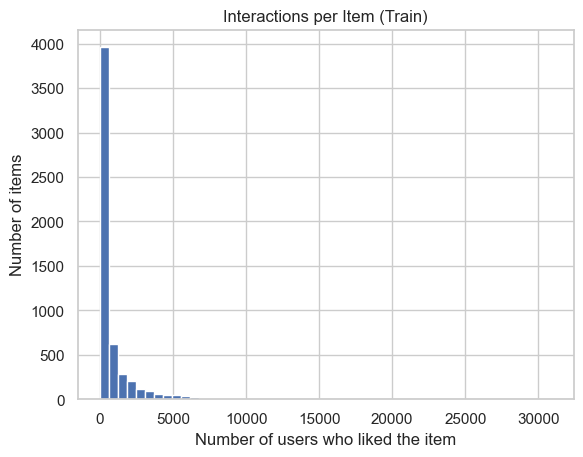

In [283]:
item_counts = train_df["item_idx"].value_counts()

plt.figure()
plt.hist(item_counts, bins=50)
plt.title("Interactions per Item (Train)")
plt.xlabel("Number of users who liked the item")
plt.ylabel("Number of items")
plt.show()

### Recommendation Models

Comparison of three recommendation algorithms on the anime ratings dataset.

#### 1. Matrix Factorization

In [422]:
user_item_mat = sp.csr_matrix(
    (
        np.ones(len(train_df), dtype=np.float32),
        (train_df["user_idx"].to_numpy(), train_df["item_idx"].to_numpy()),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

print("user_item_mat:", user_item_mat.shape, "nnz:", user_item_mat.nnz)

user_item_mat: (60384, 5609) nnz: 5130424


In [423]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    random_state=42,
    num_threads=1,
)

alpha = 40.0

user_item_conf = (user_item_mat * alpha).tocsr()

als_model.fit(user_item_conf)

assert als_model.item_factors.shape[0] == n_items
assert als_model.user_factors.shape[0] == n_users

print("ALS training complete.")


100%|██████████| 15/15 [00:13<00:00,  1.11it/s]

ALS training complete.


In [424]:
print("ALS user_factors shape:", als_model.user_factors.shape)
print("ALS item_factors shape:", als_model.item_factors.shape)

print("max user_idx in train_df:", train_df["user_idx"].max())
print("max user_idx in test_df :", test_df["user_idx"].max())
print("max user_idx in ratings_filtered:", ratings_filtered["user_idx"].max())

ALS user_factors shape: (60384, 64)
ALS item_factors shape: (5609, 64)
max user_idx in train_df: 60383
max user_idx in test_df : 60383
max user_idx in ratings_filtered: 60383


In [425]:
def als_score_fn(u, item_candidates):
    user_vec = als_model.user_factors[int(u)]
    item_vecs = als_model.item_factors[item_candidates]
    return item_vecs @ user_vec

In [426]:
def ndcg_at_k(rank, k):
    if rank is None or rank > k:
        return 0.0
    return 1.0 / np.log2(rank + 1)

In [427]:
def evaluate_sampled_topk(score_fn, test_user_item, train_user_items, num_items, k=10, num_neg=200, seed=42):
    rng = np.random.default_rng(seed)
    recalls = np.empty(len(test_user_item), dtype=np.float32)
    ndcgs = np.empty(len(test_user_item), dtype=np.float32)

    for idx, (u, true_i) in enumerate(test_user_item.items()):
        u = int(u)
        true_i = int(true_i)
        seen = train_user_items.get(u, set())

        negs = set()
        while len(negs) < num_neg:
            cand = int(rng.integers(0, num_items))
            if cand != true_i and cand not in seen:
                negs.add(cand)

        candidates = np.empty(1 + num_neg, dtype=np.int32)
        candidates[0] = true_i
        candidates[1:] = np.fromiter(negs, dtype=np.int32, count=num_neg)

        scores = score_fn(u, candidates)

        order = np.argsort(-scores)
        ranked = candidates[order]

        topk = ranked[:k]
        hit = np.any(topk == true_i)
        recalls[idx] = 1.0 if hit else 0.0

        true_rank = int(np.where(ranked == true_i)[0][0]) + 1
        ndcgs[idx] = ndcg_at_k(true_rank, k)

    return float(recalls.mean()), float(ndcgs.mean())

In [428]:
max_u_allowed = als_model.user_factors.shape[0] - 1
max_i_allowed = als_model.item_factors.shape[0] - 1

train_user_items = {u: items for u, items in train_user_items.items() if u <= max_u_allowed}
test_user_item   = {u: i for u, i in test_user_item.items() if u <= max_u_allowed and i <= max_i_allowed}

print("Users in test after ALS-range filter:", len(test_user_item))

Users in test after ALS-range filter: 60384


In [429]:
rec10, ndcg10 = evaluate_sampled_topk(
    als_score_fn,
    test_user_item=test_user_item,
    train_user_items=train_user_items,
    num_items=n_items,
    k=10,
    num_neg=200
)

print(f"ALS MF -> Recall@10: {rec10:.4f}, NDCG@10: {ndcg10:.4f}")

ALS MF -> Recall@10: 0.8433, NDCG@10: 0.5918


In [430]:
als_rec10 = rec10
als_ndcg10 = ndcg10

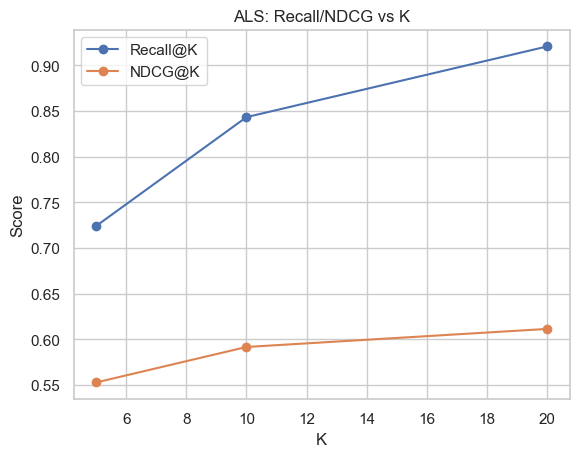

In [431]:
k_list = [5, 10, 20]
als_recalls = []
als_ndcgs = []

for k in k_list:
    r, n = evaluate_sampled_topk(
        als_score_fn,
        test_user_item=test_user_item,
        train_user_items=train_user_items,
        num_items=n_items,
        k=k,
        num_neg=200,
    )
    als_recalls.append(r)
    als_ndcgs.append(n)

plt.figure()
plt.plot(k_list, als_recalls, marker="o", label="Recall@K")
plt.plot(k_list, als_ndcgs, marker="o", label="NDCG@K")
plt.title("ALS: Recall/NDCG vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.legend()
plt.show()

In [432]:
anime_clean = anime.copy()

anime_clean["anime_id"] = anime_clean["anime_id"].astype(int)

anime_clean = anime_clean.dropna(subset=["name"])

anime_name_map = dict(zip(anime_clean["anime_id"], anime_clean["name"]))

print("anime_name_map size:", len(anime_name_map))
print("example:", list(anime_name_map.items())[:3])

anime_name_map size: 12294
example: [(32281, 'Kimi no Na wa.'), (5114, 'Fullmetal Alchemist: Brotherhood'), (28977, 'Gintama°')]


In [433]:
print("True test item_idx:", int(test_user_item[sample_user]))

true_item = test_user_item[sample_user]
true_anime_id = idx2item[int(true_item)]
true_title = anime_name_map.get(true_anime_id, "Unknown")

print("\nTrue test anime:")
print(f"{true_title} (anime_id={true_anime_id})")


True test item_idx: 393

True test anime:
Fullmetal Alchemist: The Conqueror of Shamballa (anime_id=430)


In [434]:
recs = als_model.recommend(
    userid=sample_user,
    user_items=user_item_mat[sample_user],  
    N=10,
    filter_already_liked_items=True
)

item_ids, scores = recs

print("\nTop-10 recommendations:")

for rank, (x, score) in enumerate(zip(item_ids, scores), 1):
    x = int(x)
    anime_id = idx2item[x] if x in idx2item else x
    title = anime_name_map.get(anime_id, "Unknown")
    print(f"{rank}. {title} (anime_id={anime_id}, score={float(score):.3f})")


item_ids, scores = recs



Top-10 recommendations:
1. Hunter x Hunter (2011) (anime_id=11061, score=1.197)
2. One Punch Man (anime_id=30276, score=1.144)
3. Shaman King (anime_id=154, score=1.132)
4. Kiseijuu: Sei no Kakuritsu (anime_id=22535, score=1.109)
5. Tokyo Ghoul (anime_id=22319, score=1.097)
6. Zankyou no Terror (anime_id=23283, score=1.086)
7. Bakuman. (anime_id=7674, score=1.081)
8. Bakuman. 3rd Season (anime_id=12365, score=1.068)
9. Psycho-Pass (anime_id=13601, score=1.066)
10. Death Parade (anime_id=28223, score=1.057)


#### 2. Two-Tower Model

In [556]:
import tensorflow as tf

tf.random.set_seed(42)

NUM_NEG = 20
MAX_TRAIN_SAMPLES = 1_000_000

train_pairs = train_df[["user_idx", "item_idx"]].to_numpy()
rng = np.random.default_rng(42)

if len(train_pairs) > MAX_TRAIN_SAMPLES:
    sample_idx = rng.choice(len(train_pairs), size=MAX_TRAIN_SAMPLES, replace=False)
    train_pairs = train_pairs[sample_idx]
    print(f"Downsampled train pairs to {len(train_pairs)} for faster training")

users_bpr = []
pos_bpr = []
neg_bpr = []

for (u, i) in train_pairs:
    u = int(u)
    i = int(i)
    seen = train_user_items.get(u, set())
    n_added = 0
    while n_added < NUM_NEG:
        cand = int(rng.integers(0, n_items))
        if cand != i and cand not in seen:
            users_bpr.append(u)
            pos_bpr.append(i)
            neg_bpr.append(cand)
            n_added += 1

users_bpr = np.array(users_bpr, dtype=np.int32)
pos_bpr = np.array(pos_bpr, dtype=np.int32)
neg_bpr = np.array(neg_bpr, dtype=np.int32)

labels_bpr = np.zeros(len(users_bpr), dtype=np.float32)

ds_bpr = tf.data.Dataset.from_tensor_slices(((users_bpr, pos_bpr, neg_bpr), labels_bpr))
ds_bpr = ds_bpr.shuffle(100_000, seed=42).batch(1024).prefetch(tf.data.AUTOTUNE)


Downsampled train pairs to 1000000 for faster training


In [557]:
EMB_DIM = 64

user_in = tf.keras.Input(shape=(), dtype=tf.int32, name="user")
pos_in = tf.keras.Input(shape=(), dtype=tf.int32, name="pos_item")
neg_in = tf.keras.Input(shape=(), dtype=tf.int32, name="neg_item")

user_emb = tf.keras.layers.Embedding(n_users, EMB_DIM)(user_in)
user_vec = tf.keras.layers.Flatten()(user_emb)
user_vec = tf.keras.layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(user_vec)

item_emb = tf.keras.layers.Embedding(n_items, EMB_DIM)
pos_vec = tf.keras.layers.Flatten()(item_emb(pos_in))
neg_vec = tf.keras.layers.Flatten()(item_emb(neg_in))
pos_vec = tf.keras.layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(pos_vec)
neg_vec = tf.keras.layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(neg_vec)

pos_logits = tf.keras.layers.Dot(axes=1)([user_vec, pos_vec])
neg_logits = tf.keras.layers.Dot(axes=1)([user_vec, neg_vec])
diff = tf.keras.layers.Subtract()([pos_logits, neg_logits])

def bpr_loss(y_true, y_pred):
    return -tf.reduce_mean(tf.math.log_sigmoid(y_pred))

bpr_model = tf.keras.Model([user_in, pos_in, neg_in], diff)
bpr_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=bpr_loss)

user_model = tf.keras.Model(user_in, user_vec)
item_in = tf.keras.Input(shape=(), dtype=tf.int32, name="item")
item_vec = tf.keras.layers.Flatten()(item_emb(item_in))
item_vec = tf.keras.layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(item_vec)
item_model = tf.keras.Model(item_in, item_vec)

bpr_model.summary()

Model: "functional_89"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_item            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neg_item            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_62        │ (None, 64)        │  3,864,576 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_63        │ (None, 64)        │    358,976 │ pos_item[0][0],   │
│ (Embedding)         │                   │            │ neg_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_56          │ (None, 64)        │          0 │ embedding_62[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_57          │ (None, 64)        │          0 │ embedding_63[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_58          │ (None, 64)        │          0 │ embedding_63[1][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_54 (Lambda)  │ (None, 64)        │          0 │ flatten_56[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_55 (Lambda)  │ (None, 64)        │          0 │ flatten_57[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_56 (Lambda)  │ (None, 64)        │          0 │ flatten_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_27 (Dot)        │ (None, 1)         │          0 │ lambda_54[0][0],  │
│                     │                   │            │ lambda_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_28 (Dot)        │ (None, 1)         │          0 │ lambda_54[0][0],  │
│                     │                   │            │ lambda_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_5          │ (None, 1)         │          0 │ dot_27[0][0],     │
│ (Subtract)          │                   │            │ dot_28[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,223,552 (16.11 MB)

 Trainable params: 4,223,552 (16.11 MB)

 Non-trainable params: 0 (0.00 B)

In [558]:
history = bpr_model.fit(ds_bpr, epochs=3, verbose=1)

Epoch 1/3
19532/19532 ━━━━━━━━━━━━━━━━━━━━ 123s 6ms/step - loss: 0.3295
Epoch 2/3
19532/19532 ━━━━━━━━━━━━━━━━━━━━ 117s 6ms/step - loss: 0.3245
Epoch 3/3
19532/19532 ━━━━━━━━━━━━━━━━━━━━ 118s 6ms/step - loss: 0.3260


In [559]:
user_model = tf.keras.Model(user_in, user_vec)
item_model = tf.keras.Model(item_in, item_vec)

all_items = np.arange(n_items, dtype=np.int32)
item_vecs = item_model.predict(all_items, batch_size=4096, verbose=0)

all_users = np.arange(n_users, dtype=np.int32)
user_vecs = user_model.predict(all_users, batch_size=4096, verbose=0)

item_vecs.shape, user_vecs.shape

((5609, 64), (60384, 64))

In [560]:
def tt_score_fn(u, item_candidates):
    u_vec = user_vecs[u]
    return item_vecs[item_candidates] @ u_vec

In [561]:
rec10, ndcg10 = evaluate_sampled_topk(
    tt_score_fn,
    test_user_item=test_user_item,
    train_user_items=train_user_items,
    num_items=n_items,
    k=10,
    num_neg=200,
)

print(f"Two-Tower -> Recall@10: {rec10:.4f}, NDCG@10: {ndcg10:.4f}")

Two-Tower -> Recall@10: 0.5617, NDCG@10: 0.3038


In [562]:
tt_rec10 = rec10
tt_ndcg10 = ndcg10

In [563]:
true_item = int(test_user_item[sample_user])
true_anime_id = idx2item[int(true_item)]
true_title = anime_name_map.get(true_anime_id, "Unknown")

print("True test anime:")
print(f"{true_title} (anime_id={true_anime_id})")

True test anime:
Fullmetal Alchemist: The Conqueror of Shamballa (anime_id=430)


In [564]:
seen = train_user_items.get(int(sample_user), set())
candidates = np.array([i for i in range(n_items) if i not in seen], dtype=np.int32)

scores = tt_score_fn(int(sample_user), candidates)
top_idx = np.argsort(-scores)[:10]
top_items = candidates[top_idx]

print("\nTop-10 recommendations:")
for rank, item_idx in enumerate(top_items, 1):
    anime_id = idx2item[int(item_idx)]
    title = anime_name_map.get(anime_id, "Unknown")
    print(f"{rank}. {title} (anime_id={anime_id})")



Top-10 recommendations:
1. Beelzebub (anime_id=9513)
2. Hyouka (anime_id=12189)
3. One Punch Man (anime_id=30276)
4. Tonari no Kaibutsu-kun (anime_id=14227)
5. Hellsing Ultimate (anime_id=777)
6. Psycho-Pass (anime_id=13601)
7. Guilty Crown (anime_id=10793)
8. Steins;Gate (anime_id=9253)
9. Bleach (anime_id=269)
10. Steins;Gate: Oukoubakko no Poriomania (anime_id=10863)


#### 3. Deep learning

In [445]:
if len(train_pairs) > MAX_TRAIN_SAMPLES:
    sample_idx = rng.choice(len(train_pairs), size=MAX_TRAIN_SAMPLES, replace=False)
    train_pairs = train_pairs[sample_idx]
    print(f"Downsampled train pairs to {len(train_pairs)} for faster training")

n_pos = len(train_pairs)
total = n_pos * (1 + NUM_NEG)

users_dl = np.empty(total, dtype=np.int32)
items_dl = np.empty(total, dtype=np.int32)
labels_dl = np.zeros(total, dtype=np.float32)

for p, (u, i) in enumerate(train_pairs):
    base = p * (1 + NUM_NEG)
    users_dl[base] = int(u)
    items_dl[base] = int(i)
    labels_dl[base] = 1.0

    negs = []
    seen = train_user_items.get(int(u), set())
    while len(negs) < NUM_NEG:
        cand = int(rng.integers(0, n_items))
        if cand != i and cand not in seen:
            negs.append(cand)

    users_dl[base + 1 : base + 1 + NUM_NEG] = int(u)
    items_dl[base + 1 : base + 1 + NUM_NEG] = negs

perm = rng.permutation(total)
users_dl = users_dl[perm]
items_dl = items_dl[perm]
labels_dl = labels_dl[perm]

ds_dl = tf.data.Dataset.from_tensor_slices(((users_dl, items_dl), labels_dl))
ds_dl = ds_dl.shuffle(100_000, seed=42).batch(1024).prefetch(tf.data.AUTOTUNE)


In [446]:
u_in = tf.keras.Input(shape=(), dtype=tf.int32, name="user")
i_in = tf.keras.Input(shape=(), dtype=tf.int32, name="item")

u_emb = tf.keras.layers.Embedding(n_users, EMB_DIM)(u_in)
i_emb = tf.keras.layers.Embedding(n_items, EMB_DIM)(i_in)

u_vec = tf.keras.layers.Flatten()(u_emb)
i_vec = tf.keras.layers.Flatten()(i_emb)

x = tf.keras.layers.Concatenate()([u_vec, i_vec])
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

dl_model = tf.keras.Model([u_in, i_in], out)
dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")],
)

dl_model.summary()


Model: "functional_62"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_44        │ (None, 64)        │  3,864,576 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_45        │ (None, 64)        │    358,976 │ item[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_32          │ (None, 64)        │          0 │ embedding_44[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_33          │ (None, 64)        │          0 │ embedding_45[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128)       │          0 │ flatten_32[0][0], │
│ (Concatenate)       │                   │            │ flatten_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 128)       │     16,512 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 1)         │         65 │ dense_37[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,248,385 (16.21 MB)

 Trainable params: 4,248,385 (16.21 MB)

 Non-trainable params: 0 (0.00 B)

In [447]:
history_dl = dl_model.fit(ds_dl, epochs=3, verbose=1)

Epoch 1/3
10743/10743 ━━━━━━━━━━━━━━━━━━━━ 68s 6ms/step - auc: 0.8872 - loss: 0.2055
Epoch 2/3
10743/10743 ━━━━━━━━━━━━━━━━━━━━ 68s 6ms/step - auc: 0.9172 - loss: 0.1819
Epoch 3/3
10743/10743 ━━━━━━━━━━━━━━━━━━━━ 67s 6ms/step - auc: 0.9344 - loss: 0.1644


In [448]:
def dl_score_fn(u, item_candidates):
    u_arr = np.full(len(item_candidates), u, dtype=np.int32)
    preds = dl_model.predict([u_arr, item_candidates], batch_size=4096, verbose=0).reshape(-1)
    return preds

In [449]:
num_neg_dl_eval = 50
max_eval_users = 1000

if len(test_user_item) > max_eval_users:
    test_user_item_eval = dict(list(test_user_item.items())[:max_eval_users])
else:
    test_user_item_eval = test_user_item

rec10, ndcg10 = evaluate_sampled_topk(
    dl_score_fn,
    test_user_item=test_user_item_eval,
    train_user_items=train_user_items,
    num_items=n_items,
    k=10,
    num_neg=num_neg_dl_eval,
)

dl_rec10 = rec10
dl_ndcg10 = ndcg10
print(f"DL MLP -> Recall@10: {rec10:.4f}, NDCG@10: {ndcg10:.4f}")


DL MLP -> Recall@10: 0.9050, NDCG@10: 0.6334


In [450]:
true_item = int(test_user_item[sample_user])
true_anime_id = idx2item[int(true_item)]
true_title = anime_name_map.get(true_anime_id, "Unknown")

print("True test anime:")
print(f"{true_title} (anime_id={true_anime_id})")

True test anime:
Fullmetal Alchemist: The Conqueror of Shamballa (anime_id=430)


In [451]:
seen = train_user_items.get(int(sample_user), set())
candidates = np.array([i for i in range(n_items) if i not in seen], dtype=np.int32)

dl_scores = dl_score_fn(int(sample_user), candidates)
dl_top_idx = np.argsort(-dl_scores)[:10]
dl_top_items = candidates[dl_top_idx]

print("\nTop-10 recommendations:")
for rank, item_idx in enumerate(dl_top_items, 1):
    anime_id = idx2item[int(item_idx)]
    title = anime_name_map.get(anime_id, "Unknown")
    print(f"{rank}. {title} (anime_id={anime_id})")


Top-10 recommendations:
1. Tokyo Ghoul (anime_id=22319)
2. Psycho-Pass (anime_id=13601)
3. Hunter x Hunter (2011) (anime_id=11061)
4. One Punch Man (anime_id=30276)
5. Code Geass: Hangyaku no Lelouch (anime_id=1575)
6. Durarara!! (anime_id=6746)
7. Shigatsu wa Kimi no Uso (anime_id=23273)
8. Ouran Koukou Host Club (anime_id=853)
9. Kiseijuu: Sei no Kakuritsu (anime_id=22535)
10. Death Parade (anime_id=28223)


### Poredjenje algoritama

In [565]:
als_top10 = [int(x) for x in item_ids]

tt_top10 = [int(x) for x in top_items]

dl_top10 = [int(x) for x in dl_top_items]

def to_titles(item_idx_list):
    out = []
    for idx in item_idx_list:
        aid = idx2item.get(int(idx), int(idx))
        out.append(anime_name_map.get(aid, "Unknown"))
    return out

def overlap(a, b):
    return sorted(set(a) & set(b))

o_at = overlap(als_top10, tt_top10)
o_ad = overlap(als_top10, dl_top10)
o_td = overlap(tt_top10, dl_top10)

print("ALS - Two-Tower:", len(o_at), to_titles(o_at))
print("ALS - DL:", len(o_ad), to_titles(o_ad))
print("Two-Tower - DL:", len(o_td), to_titles(o_td))

ALS - Two-Tower: 2 ['Psycho-Pass', 'One Punch Man']
ALS - DL: 6 ['Hunter x Hunter (2011)', 'Psycho-Pass', 'Tokyo Ghoul', 'Kiseijuu: Sei no Kakuritsu', 'Death Parade', 'One Punch Man']
Two-Tower - DL: 2 ['Psycho-Pass', 'One Punch Man']


In [566]:
seen = train_user_items.get(int(sample_user), set())
candidates = np.array([i for i in range(n_items) if i not in seen], dtype=np.int32)
print("candidate count:", len(candidates))

als_top10 = [int(x) for x in item_ids]
print("ALS top10 item_idx:", als_top10)

tt_scores_all = tt_score_fn(int(sample_user), candidates)
tt_top_idx = np.argsort(-tt_scores_all)[:10]
tt_top10 = [int(x) for x in candidates[tt_top_idx]]
print("Two-Tower top10 item_idx:", tt_top10)

dl_scores_all = dl_score_fn(int(sample_user), candidates)
dl_top_idx = np.argsort(-dl_scores_all)[:10]
dl_top10 = [int(x) for x in candidates[dl_top_idx]]
print("DL top10 item_idx:", dl_top10)


candidate count: 5538
ALS top10 item_idx: [3892, 5304, 130, 4879, 4871, 4934, 3285, 4039, 4169, 5187]
Two-Tower top10 item_idx: [3546, 4023, 5304, 4218, 683, 4169, 3831, 3510, 241, 3858]
DL top10 item_idx: [4871, 4169, 3892, 5304, 1339, 3126, 4931, 742, 4879, 5187]


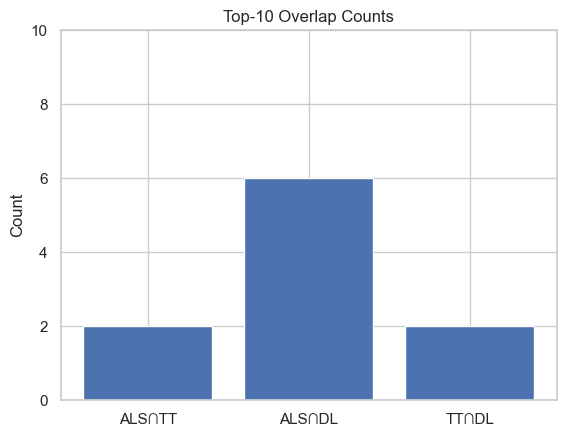

In [567]:
als_top10 = [int(x) for x in item_ids]
tt_top10 = [int(x) for x in top_items]
dl_top10 = [int(x) for x in dl_top_items]

o_at = len(set(als_top10) & set(tt_top10))
o_ad = len(set(als_top10) & set(dl_top10))
o_td = len(set(tt_top10) & set(dl_top10))

labels = ["ALS∩TT", "ALS∩DL", "TT∩DL"]
vals = [o_at, o_ad, o_td]
plt.figure()
plt.bar(labels, vals)
plt.title("Top-10 Overlap Counts")
plt.ylabel("Count")
plt.ylim(0, 10)
plt.show()


In [568]:
def to_titles(item_idx_list):
    out = []
    for idx in item_idx_list:
        aid = idx2item.get(int(idx), int(idx))
        out.append(anime_name_map.get(aid, "Unknown"))
    return out

top10_titles = {
    "ALS": to_titles(als_top10),
    "Two-Tower": to_titles(tt_top10),
    "DL MLP": to_titles(dl_top10),
}
display(pd.DataFrame(top10_titles))


,ALS,Two-Tower,DL MLP
0,Hunter x Hunter (2011),Beelzebub,Tokyo Ghoul
1,One Punch Man,Hyouka,Psycho-Pass
2,Shaman King,One Punch Man,Hunter x Hunter (2011)
3,Kiseijuu: Sei no Kakuritsu,Tonari no Kaibutsu-kun,One Punch Man
4,Tokyo Ghoul,Hellsing Ultimate,Code Geass: Hangyaku no Lelouch
5,Zankyou no Terror,Psycho-Pass,Durarara!!
6,Bakuman.,Guilty Crown,Shigatsu wa Kimi no Uso
7,Bakuman. 3rd Season,Steins;Gate,Ouran Koukou Host Club
8,Psycho-Pass,Bleach,Kiseijuu: Sei no Kakuritsu
9,Death Parade,Steins;Gate: Oukoubakko no Poriomania,Death Parade


,Recall@10,NDCG@10
ALS,0.960354,0.784221
Two-Tower,0.561689,0.303812
DL MLP,0.905000,0.633368


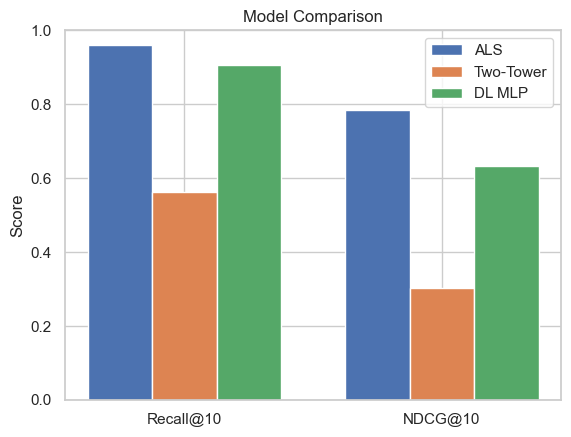

In [569]:
results = {
    "ALS": {"Recall@10": als_rec10, "NDCG@10": als_ndcg10},
    "Two-Tower": {"Recall@10": tt_rec10, "NDCG@10": tt_ndcg10},
    "DL MLP": {"Recall@10": dl_rec10, "NDCG@10": dl_ndcg10},
}
display(pd.DataFrame(results).T)

labels = ["Recall@10", "NDCG@10"]
x = np.arange(len(labels))
w = 0.25
plt.figure()
plt.bar(x - w, [results["ALS"][l] for l in labels], width=w, label="ALS")
plt.bar(x,     [results["Two-Tower"][l] for l in labels], width=w, label="Two-Tower")
plt.bar(x + w, [results["DL MLP"][l] for l in labels], width=w, label="DL MLP")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()